# __Factors Associated with ROSC in Cardiac Arrest Patients: An EMS Data Study__

## __Introduction__

Cardiac arrest is a life-threatening emergency with high mortality, where rapid intervention is critical for survival. One of the key early outcomes in successful resuscitation is the Return of Spontaneous Circulation (ROSC), which represents the restoration of a sustained pulse and effective blood flow. Understanding the factors associated with ROSC can help guide both prehospital care and clinical decision-making.

In the prehospital setting, Emergency Medical Services (EMS) providers play a crucial role in determining patient outcomes. Variables such as __initial cardiac rhythm, early defibrillation, bystander intervention, and timing of arrest__ may significantly influence the likelihood of ROSC.

This project analyzes EMS cardiac arrest data to identify patterns and factors associated with successful resuscitation. The analysis focuses on both __pre-EMS conditions__ (such as AED use and initial rhythm) and __EMS interventions__ (such as CPR and defibrillation), and further explores these relationships using a __logistic regression model__.

The goal of this analysis is not to establish causation, but to uncover meaningful associations that align with clinical understanding and demonstrate how data can be used to evaluate real-world emergency care outcomes.

### Dataset Overview

The dataset used in this analysis consists of __EMS patient care reports for cardiac arrest incidents__. Each row represents a single patient encounter, identified by a unique record key.

The dataset includes variables describing:

- __Patient condition and event context__
    - Cardiac arrest timing (before vs after EMS arrival)
    - Initial cardiac rhythm (e.g., asystole, PEA, shockable rhythms)
    - Symptoms and initial acuity
- __Pre-EMS interventions__
    - Automated External Defibrillator (AED) use prior to EMS arrival
- __EMS interventions__
    - CPR and defibrillation status
    - Medications administered (e.g., epinephrine)
    - Procedures performed
- __Outcome__
    - Return of Spontaneous Circulation (ROSC), represented as a binary variable (0 = no ROSC, 1 = ROSC)
    - Final acuity

The dataset was cleaned and transformed from multiple source tables into a single analytical dataset, with categorical variables standardized and key clinical features engineered for analysis.

Missing or unspecified initial cardiac rhythm values were categorized as "Unknown" during preprocessing. For clarity of interpretation, this category was excluded from summary tables and visualizations, but retained in the regression model to preserve sample size.

Certain NEMSIS variables used coded placeholder values for unknown or unavailable responses rather than standard null values. These were consolidated into interpretable categories during preprocessing.

The final dataset contains approximately __274,000 patients and 20 features__.

### Data Source

This analysis uses data from the [National Emergency Medical Services Information System (NEMSIS)](https://nemsis.org), specifically the __2023 Cardiac Arrest Public Release Research Dataset__.

NEMSIS is a national database that aggregates standardized EMS patient care reports from across the United States, providing a comprehensive resource for studying prehospital emergency care.

The dataset is publicly available at the NEMSIS website for research and analysis purposes.

### Setup and Data Loading

This section imports required libraries and loads the cleaned dataset used for analysis.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from IPython.display import display
from matplotlib.ticker import PercentFormatter
import sys
from pathlib import Path

figures_path = Path("../figures")
figures_path.mkdir(exist_ok=True)

sys.path.insert(0, str(Path("../src").resolve()))
from processing import simplify_rhythm

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Load dataset
df = pd.read_csv("../outputs/cleaned_data.csv")

In [2]:
print(df.shape)
df.head(3)

(274531, 20)


,PcrKey,Response_Type,Arrest,Arrest_Etiology,AED_Prior_to_EMS,Initial_Rhythm,End_of_EMS_Cardiac_Event,Initial_Acuity,Final_Acuity,epi_count,epi_given,total_medications,unique_medications,defibrillation_status,CPR_status,total_procedures,unique_procedures,ROSC,Symptoms,intervention_intensity
0,225614118.0,Ground,"Yes, Prior to Any EMS Arrival",Cardiac Etiology (presumed),No,Asystole,Expired in the Field,NaN,NaN,0,0,0,0,0,0,1,1,0,Cardiovascular,0
1,225614544.0,Ground,"Yes, Prior to Any EMS Arrival",Cardiac Etiology (presumed),No,NaN,Expired in the Field,NaN,NaN,2,1,3,2,1,1,5,4,0,Cardiovascular,8
2,225614812.0,Ground,"Yes, Prior to Any EMS Arrival",Cardiac Etiology (presumed),NaN,NaN,NaN,Emergent (Yellow),Emergent (Yellow),8,1,10,2,0,1,5,5,0,Symptoms/Unknown,15


## __Pre-EMS Factors__

Outcomes in cardiac arrest are heavily influenced by conditions present before EMS arrival. This section examines how initial rhythm, AED use, and timing of arrest are associated with ROSC rates.

### Association of Initial Cardiac Rhythm with ROSC

Initial cardiac rhythm is one of the strongest predictors of survival. This analysis compares ROSC rates across different rhythm categories.

In [3]:
df["Initial_Rhythm"] = df["Initial_Rhythm"].fillna("Unknown")
df["Rhythm_Clean"] = df["Initial_Rhythm"].apply(simplify_rhythm)

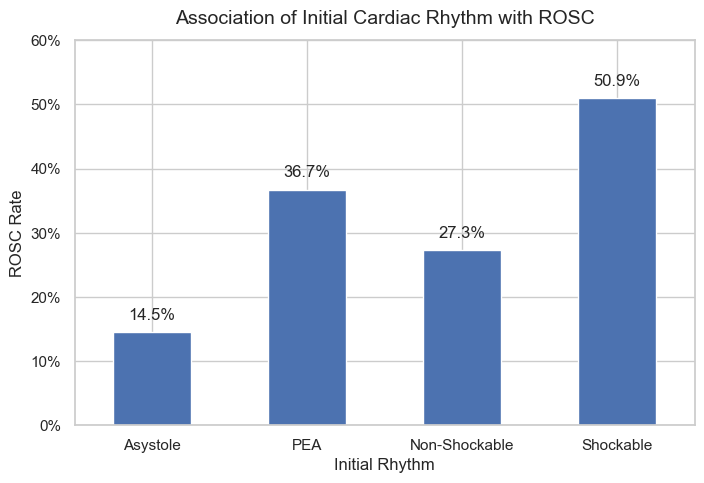

In [4]:
order = ["Asystole", "PEA", "Non-Shockable", "Shockable"]

rates = df[df["Rhythm_Clean"] != "Unknown"]

rates = (
    rates.groupby("Rhythm_Clean")["ROSC"]
    .mean()
    .reindex(order)
)

rates.plot(kind="bar")

for i, v in enumerate(rates):
    plt.text(i, v + 0.02, f"{v:.1%}", ha="center")

plt.title("Association of Initial Cardiac Rhythm with ROSC", fontsize=14, pad=12)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.ylabel("ROSC Rate")
plt.xlabel("Initial Rhythm")
plt.ylim(0, 0.6)
plt.xticks(rotation=0)
plt.savefig(figures_path / "rosc_by_rhythm.png", dpi=300, bbox_inches="tight")
plt.show()

Shockable rhythms demonstrate the highest ROSC rate (~51%), while asystole shows significantly lower outcomes (~14%). This aligns with clinical expectations that shockable rhythms respond more favorably to defibrillation.

### Association of AED Use Prior to EMS Arrival with ROSC

Early defibrillation is one of the most important interventions in out-of-hospital cardiac arrest. This analysis evaluates the relationship between AED use prior to EMS arrival and ROSC, distinguishing between cases where defibrillation was delivered versus not delivered.

In [5]:
label_map = {
    "No": "No AED",
    "Yes, Applied without Defibrillation": "AED (No Shock)",
    "Yes, with Defibrillation": "AED (Shock)"
}
df["AED_clean"] = df["AED_Prior_to_EMS"].map(label_map)

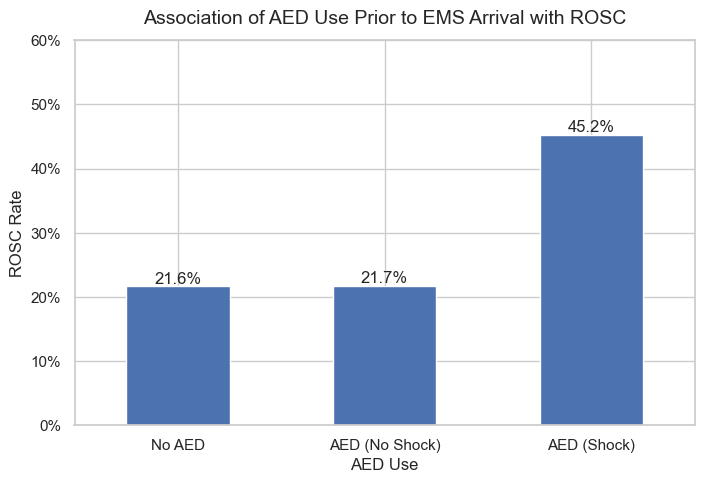

In [6]:
order = ["No AED", "AED (No Shock)", "AED (Shock)"]

aed_rosc = (
    df.groupby("AED_clean")["ROSC"]
    .mean()
    .reindex(order)
)

ax = aed_rosc.plot(kind="bar")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1%}",
                (p.get_x() +
                p.get_width() / 2, p.get_height()),
                ha="center",
                va="bottom")

plt.title("Association of AED Use Prior to EMS Arrival with ROSC", fontsize=14, pad=12)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.ylabel("ROSC Rate")
plt.xlabel("AED Use")
plt.ylim(0, 0.6)
plt.xticks(rotation=0)
plt.savefig(figures_path / "rosc_by_aed_use.png", dpi=300, bbox_inches="tight")
plt.show()

ROSC rates are substantially higher when AED use includes defibrillation (~45%) compared to no AED use (~21%). Cases where an AED was applied without delivering a shock show similar outcomes to no AED use, suggesting that the benefit is driven primarily by defibrillation itself.

### Association of Cardiac Arrest Timing Relative to EMS Arrival with ROSC

The timing of cardiac arrest relative to EMS arrival can significantly impact survival outcomes. Arrests occuring after EMS arrival may benefit from immediate medical intervention, while those occuring prior to arrival depend on bystander response and early care. This analysis compares ROSC rates between these two groups.

In [7]:
mapping = {
    "Yes, After Any EMS Arrival": "After EMS Arrival",
    "Yes, Prior to Any EMS Arrival": "Before EMS Arrival"
}

df["Arrest_Simplified"] = df["Arrest"].map(mapping)

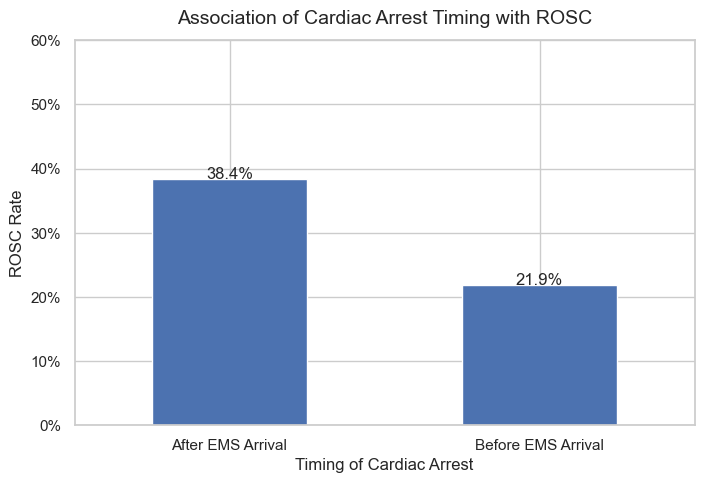

In [8]:
arrest_rosc = df.groupby("Arrest_Simplified")["ROSC"].mean()

arrest_rosc.plot(kind="bar")

for i, v in enumerate(arrest_rosc.values):
    plt.text(i, v + 0.001, f"{v:.1%}", ha="center")

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.ylabel("ROSC Rate")
plt.xlabel("Timing of Cardiac Arrest")
plt.title("Association of Cardiac Arrest Timing with ROSC", fontsize=14, pad=12)
plt.xticks(rotation=0)
plt.ylim(0, 0.6)
plt.show()

ROSC rates are notably higher when cardiac arrest occurs after EMS arrival (~38%) compared to prior to EMS arrival (~22%). This likely reflects the benefit of immediate professional intervention, including rapid CPR, defibrillation, and advanced life support.

The substantial increase in ROSC when arrest occurs after EMS arrival highlights the critical role of response time and immediate medical care in cardiac arrest survival.

## __Impact of EMS Interventions on ROSC__

EMS interventions play a critical role in cardiac arrest management and may significantly influence patient outcomes. This section examines how key interventions- including CPR, defibrillation, and medication administration- are associated with ROSC.

### Association of EMS-Administered CPR with ROSC

CPR is a cornerstone of cardiac arrest resuscitation. In this dataset, CPR status specifically reflects interventions performed by EMS personnel, not bystanders. This analysis evaluates the association between EMS-administered CPR and ROSC outcomes.

In [9]:
df["CPR_label"] = df["CPR_status"].map({0: "No CPR", 1: "CPR"})

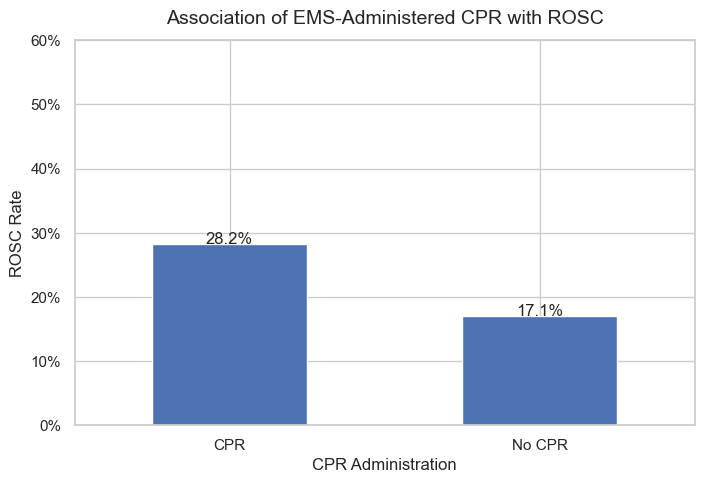

In [10]:
rosc_rate_cpr = df.groupby("CPR_label")["ROSC"].mean()
rosc_rate_cpr.plot(kind="bar")

for i, v in enumerate(rosc_rate_cpr.values):
    plt.text(i, v + 0.001, f"{v:.1%}", ha="center")

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.ylabel("ROSC Rate")
plt.xlabel("CPR Administration")
plt.title("Association of EMS-Administered CPR with ROSC", fontsize=14, pad=12)
plt.xticks(rotation=0)
plt.ylim(0, 0.6)
plt.savefig(figures_path / "cpr_vs_rosc.png", dpi=300, bbox_inches="tight")
plt.show()

Patients who received EMS-administered CPR had higher ROSC rates (~28%) compared to those who did not (~17%). This likely reflects the importance of resuscitative efforts, though it may also be influenced by differences in arrest severity and timing.

### Association of Defibrillation with ROSC

Defibrillation is a critical intervention for shockable cardiac rhythms and is strongly associated with improved survival outcomes. In this dataset, defibrillation status reflects shocks delivered by EMS personnel.

This analysis examines the association between EMS-administered defibrillation and ROSC.

In [11]:
df["defibrillation_label"] = df["defibrillation_status"].map({0: "No Defibrillation", 1: "Defibrillation"})
rosc_rate_defib = df.groupby("defibrillation_label")["ROSC"].mean()

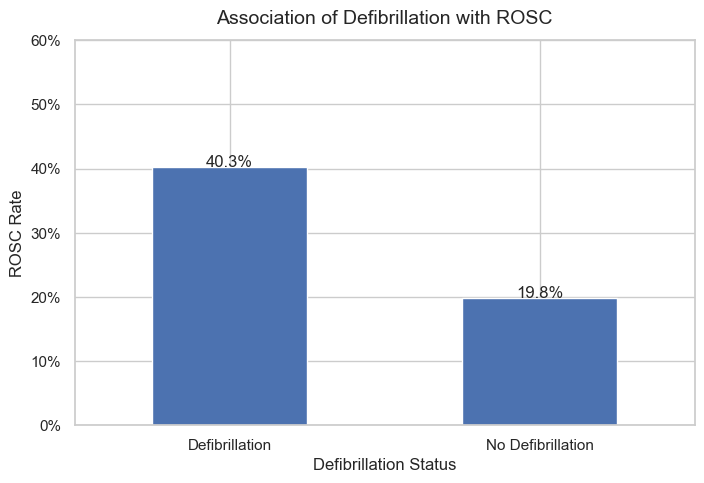

In [12]:
rosc_rate_defib.plot(kind="bar")

for i, v in enumerate(rosc_rate_defib.values):
    plt.text(i, v + 0.001, f"{v:.1%}", ha="center")

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.ylabel("ROSC Rate")
plt.xlabel("Defibrillation Status")
plt.title("Association of Defibrillation with ROSC", fontsize=14, pad=12)
plt.xticks(rotation=0)
plt.ylim(0, 0.6)
plt.savefig(figures_path / "defibrillation_vs_rosc.png", dpi=300, bbox_inches="tight")
plt.show()

Patients who received defibrillation had substantially higher ROSC rates (~40%) compared to those who did not (~20%). This finding aligns with established clinical evidence that early defibrillation is a key determinant of survival in cardiac arrest.

However, this association is influenced by the underlying cardiac rhythm, as defibrillation is primarily indicated for shockable rhythms, which inherently have better outcomes. Therefore, the observed effect likely reflects both the benefit of defibrillation and the characteristics of patients who receive it.

This relationship is further evaluated in the multivariate model to assess its independent effect.

### Association of Medication Burden with ROSC

Medication administration during cardiac arrest reflects the intensity and duration of resuscitation efforts. This analysis examines whether the total number of medications administered is associated with ROSC outcomes.

In [13]:
df["ROSC_label"] = df["ROSC"].map({0: "No ROSC", 1: "ROSC"})

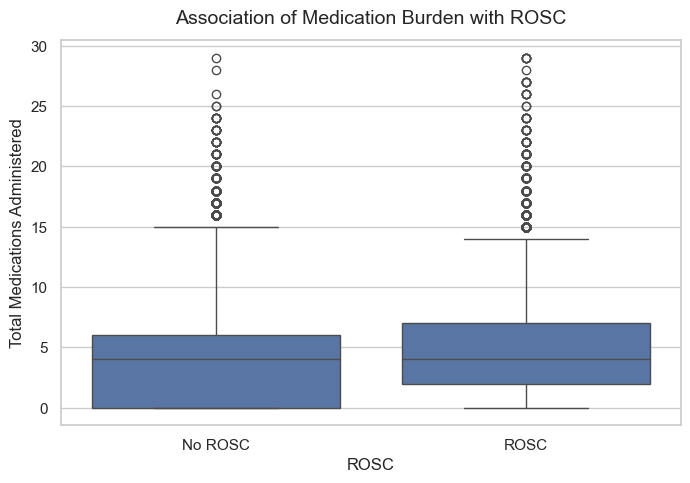

In [14]:
sns.boxplot(x="ROSC_label", y="total_medications", data=df)
plt.title("Association of Medication Burden with ROSC", fontsize=14, pad=12)
plt.xlabel("ROSC")
plt.ylabel("Total Medications Administered")
plt.show()

Total medication count showed substantial overlap between ROSC and non-ROSC groups, with only minimal differences in median values.

Patients who achieved ROSC did not receive fewer medications; in fact, slightly higher medication counts were observed in some cases. This suggests that medication burden alone is not a strong independent predictor of ROSC.

Instead, higher medication counts likely reflect longer or more complex resuscitation efforts rather than directly improving outcomes. This highlights the importance of early, high-impact interventions—such as defibrillation and CPR—over cumulative medication administration.

This finding aligns with the concept that medication use is often reactive to prolonged arrest rather than a primary driver of successful resuscitation.

## Predictive Modeling: Adjusted Odds Ratios for ROSC

Descriptive analyses provide insight into individual relationships between variables and ROSC, but they do not account for potential confounding between predictors.

To address this, a multivariable logistic regression model was constructed to evaluate the independent effects of key clinical factors on ROSC. This method estimates odds ratios, allowing for interpretation of both the strength and direction of each association while controlling for other variables.

This approach provides a more robust understanding of which factors are most strongly associated with successful resuscitation.

### Multivariate Logistic Regression Analysis of ROSC

The table below presents the results of the multivariable logistic regression analysis, summarizing the independent association between each predictor and ROSC.

Odds ratios quantify the strength and direction of these relationships. An odds ratio greater than 1 indicates increased odds of ROSC, whereas values below 1 indicate decreased odds, after controlling for other variables in the model.

Key predictors are interpreted below based on their relative effect sizes.

In [15]:
features_dict = {
    "defibrillation_status": "Defibrillation",
    "CPR_status": "CPR",
    "epi_count": "Epinephrine Count"
}

interpretation = ["Slight negative / severity-associated", "Moderate positive association", "Strong positive association"]
interpretation_series = pd.Series(interpretation)

In [16]:
X = df[["epi_count", "CPR_status", "defibrillation_status"]]
y = df["ROSC"]

model = LogisticRegression()
model.fit(X, y)

coef = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_[0]}) \
    .sort_values(by="Coefficient", ascending=False)
coef["Odds Ratio"] = np.exp(coef["Coefficient"]).round(2)

coef["Feature"] = coef["Feature"].map(features_dict)
coef["Interpretation"] = interpretation_series

coef["Odds Ratio"] = coef["Odds Ratio"].map("{:.2f}".format)

final_table = coef[["Feature", "Odds Ratio", "Interpretation"]]

pd.set_option('display.max_columns', None)

display(
    final_table.style
    .set_properties(**{'font-size':
                       '14pt'})
    .set_table_styles([
        {'selector': 'th', 'props':
         [('font-size', '16pt')]}
    ])
    .hide(axis='index')
)

Feature,Odds Ratio,Interpretation
Defibrillation,2.58,Strong positive association
CPR,1.85,Moderate positive association
Epinephrine Count,0.94,Slight negative / severity-associated


Defibrillation was the strongest predictor of ROSC, with patients receiving defibrillation having over 2.5 times the odds of achieving ROSC compared to those who did not. CPR was also associated with increased odds of ROSC, though to a lesser degree.

In contrast, epinephrine count showed a slight negative association with ROSC. This likely reflects the fact that higher epinephrine use is associated with prolongued or more severe cardiac arrest rather than directly reducing the likelihood of ROSC.

Overall, these findings highlight that early, high-impact interventions- particularly defibrillation- are more strongly associated with successful resuscitation than cumulative medication administration.

These results are consistent with established resuscitation principles emphasizing rapid defibrillation and high-quality CPR as primary drivers of survival.

The figure below visualizes the odds ratios for each predictor, highlighting the relative strength and direction of their associations with ROSC.

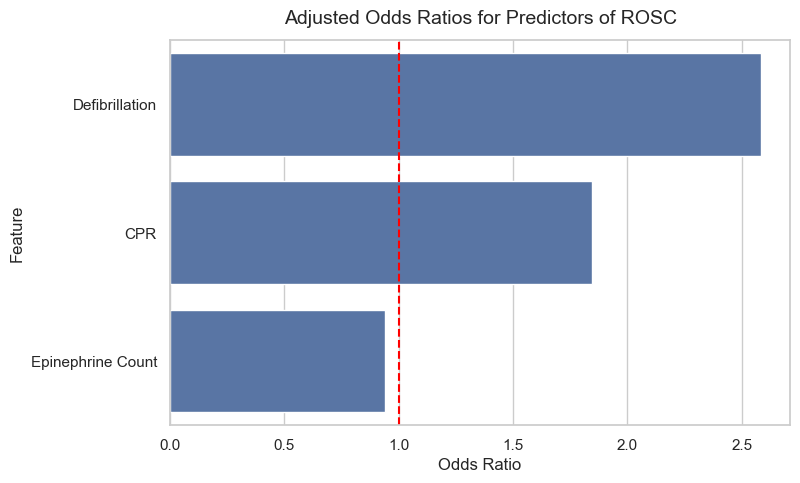

In [17]:
features = ["epi_count", "CPR_status", "defibrillation_status"]
odds_ratio = np.exp(model.coef_[0])

or_df = pd.DataFrame({
    "feature": features,
    "odds_ratio": odds_ratio
}).sort_values(by="odds_ratio", ascending=False)

or_df["Feature"] = or_df["feature"].map(features_dict)

sns.barplot(x="odds_ratio", y="Feature", data=or_df)
plt.axvline(1, color="red", linestyle="--")
plt.title("Adjusted Odds Ratios for Predictors of ROSC", fontsize=14, pad=12)
plt.xlabel("Odds Ratio")
plt.ylabel("Feature")
plt.show()

### Expanded Logistic Regression Including Initial Rhythm

To further evaluate the independent effects of EMS interventions, initial cardiac rhythm was added to the logistic regression model as a categorical variable using one-hot encoding, with asystole serving as the reference group.

Given that rhythm is a major determinant of survival, this model assesses whether interventions such as defibrillation and CPR remain significant predictors after accounting for underlying cardiac physiology.

In [18]:
features_dict = {
    "defibrillation_status": "Defibrillation",
    "CPR_status": "CPR",
    "epi_count": "Epinephrine Count",
    "rhythm_Shockable": "Shockable Rhythm",
    "rhythm_PEA": "PEA",
    "rhythm_Non-Shockable": "Non-Shockable Rhythm"
}

rhythms = ["Shockable Rhythm", "PEA", "Non-Shockable Rhythm"]

In [19]:
rhythm_dummies = pd.get_dummies(df["Rhythm_Clean"], prefix="rhythm", drop_first=True)

X = pd.concat([df[["defibrillation_status", "CPR_status", "epi_count"]], rhythm_dummies], axis=1)
y = df["ROSC"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

odds_ratios = np.exp(model.coef_[0])

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Odds Ratio": odds_ratios
}).sort_values(by="Odds Ratio", ascending=False)

coef_df = coef_df[coef_df["Feature"] != "rhythm_Unknown"]

coef_df["Feature"] = coef_df["Feature"].map(features_dict)
coef_df["Odds Ratio"] = coef_df["Odds Ratio"].map("{:.2f}".format)

To improve interpretability, model features were grouped into two categories: baseline patient condition (initial cardiac rhythm) and EMS interventions. This distinction allows for clearer interpretation of intrinsic patient factors versus modifiable treatment effects.

##### Rhythm Predictors of ROSC (Adjusted Model)

In [20]:
rhythm_df = coef_df[coef_df["Feature"].isin(rhythms)]

interpretation_r = ["Strong independent association with ROSC", "Moderate independent association with ROSC",
                    "Positive association vs reference rhythm"]
interpretation_r_series = pd.Series(interpretation_r)

interpretation_r_series.index = rhythm_df.index
rhythm_df["Interpretation"] = interpretation_r_series

display(
    rhythm_df.style
    .set_properties(**{'font-size':
                       '14pt'})
    .set_table_styles([
        {'selector': 'th', 'props':
         [('font-size', '16pt')]}
    ])
    .hide(axis='index')
)

Feature,Odds Ratio,Interpretation
Shockable Rhythm,5.33,Strong independent association with ROSC
PEA,3.16,Moderate independent association with ROSC
Non-Shockable Rhythm,2.17,Positive association vs reference rhythm


##### EMS Intervention Predictors of ROSC (Adjusted Model)

In [21]:
treatments = ["Defibrillation", "CPR", "Epinephrine Count"]
treatment_df = coef_df[coef_df["Feature"].isin(treatments)]
interpretation_t = ["Strong independent association with ROSC", "Moderate independent association", "Slight negative / severity-associated"]
interpretation_t_series = pd.Series(interpretation_t)

interpretation_t_series.index = treatment_df.index
treatment_df["Interpretation"] = interpretation_t_series

display(
    treatment_df.style
    .set_properties(**{'font-size':
                       '14pt'})
    .set_table_styles([
        {'selector': 'th', 'props':
         [('font-size', '16pt')]}
    ])
    .hide(axis='index')
)

Feature,Odds Ratio,Interpretation
Defibrillation,2.09,Strong independent association with ROSC
CPR,1.82,Moderate independent association
Epinephrine Count,0.96,Slight negative / severity-associated


The figure below visualizes the adjusted odds ratio for each predictor, highlighting their relative contributions to ROSC.

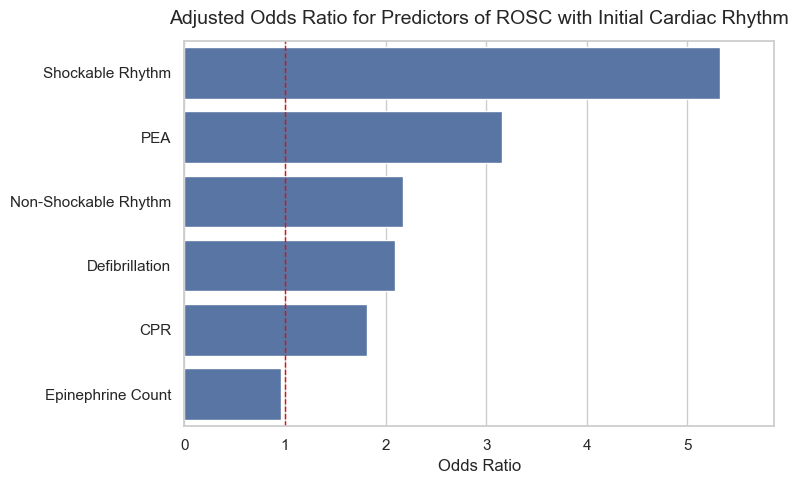

In [22]:
coef_df["Odds Ratio"] = coef_df["Odds Ratio"].astype(float)

coef_df = coef_df.sort_values("Odds Ratio", ascending=False)

plt.figure(figsize=(8, 5))

sns.barplot(
    x="Odds Ratio",
    y="Feature",
    data=coef_df,
    orient="h"
)

plt.axvline(1, color="red", linestyle="--", linewidth=1)

plt.title("Adjusted Odds Ratio for Predictors of ROSC with Initial Cardiac Rhythm", fontsize=14, pad=12)
plt.xlabel("Odds Ratio")
plt.ylabel("")

plt.xlim(0, coef_df["Odds Ratio"].max() * 1.1)

plt.tight_layout()
plt.savefig(figures_path / "adjusted_odds_ratios.png", dpi=300, bbox_inches="tight")
plt.show()

After adjusting for both patient condition and EMS interventions, initial cardiac rhythm emerged as the strongest predictor of ROSC. Shockable rhythms demonstrated markedly higher odds of survival (OR ~= 5.33), followed by PEA (OR ~= 3.16) and other non-shockable rhythms (OR ~= 2.17), confirming the critical role of underlying cardiac pathology.

Among EMS interventions, defibrillation remained a strong independent predictor (OR ~= 2.09), while CPR showed a moderate positive association (OR ~= 1.82). Epinephrine count demonstrated a near-neutral to slightly negative association (OR ~= 0.96), likely reflecting increased use in prolonged or more severe resuscitation efforts rather than a direct causal effect.

Overall, these findings suggest that while EMS interventions contribute meaningfully to ROSC, initial cardiac rhythm is the dominant determinant of survival.

## __Key Findings__

This analysis identified several important predictors of return of spontaneous circulation (ROSC) in out-of-hospital cardiac arrest cases.

Initial cardiac rhythm emerged as the strongest predictor of ROSC. Shockable rhythms were associated with significantly higher odds of ROSC compared to non-shockable rhythms, highlighting the critical importance of early rhythm identification.

Defibrillation also demonstrated a strong positive association with ROSC, reinforcing its role as a key life-saving intervention, particularly in patients with shockable rhythms.

EMS-administered CPR showed a moderate positive association with ROSC. However, CPR is performed broadly across nearly all cardiac arrest presentations, including patients with non-shockable rhythms and poorer overall prognoses. As a result, the observed effect size may underestimate the true clinical importance of CPR, since the intervention is disproportionately applied in more severe or less survivable cases.

Epinephrine administration showed a slight negative or weak association with ROSC. This likely reflects confounding by severity, as higher medication use may indicate prolonged or more complex resuscitation efforts.

Timing of cardiac arrest relative to EMS arrival was also significant. Patients who arrested after EMS arrival had higher ROSC rates, emphasizing the importance of immediate intervention.

Finally, overall medication burden showed minimal differentiation between outcomes, further supporting the idea that increased intervention intensity may reflect severity rather than improved outcomes.

## __Limitations__

This analysis has several important limitations. First, the study was based on observational EMS data from the NEMSIS Cardiac Arrest Subset 2023 dataset and therefore cannot establish causation. The identified associations describe relationships with ROSC but do not prove that individual interventions directly caused improved outcomes.

Several variables may also reflect underlying patient severity rather than treatment effectiveness. For example, higher epinephrine counts and greater intervention intensity are often associated with prolonged or more severe resuscitation attempts, which may confound interpretation.

Additionally, EMS interventions such as CPR are broadly administered across nearly all cardiac arrest presentations, including patients with poor baseline prognoses and non-shockable rhythms. This may reduce the apparent independent effect of CPR within the predictive models.

The dataset also contained missing and unknown values, particularly within cardiac rhythm classifications. Unknown rhythm categories were excluded from portions of the regression analysis to improve interpretability, which may have affected model estimates. Although the underlying NEMSIS dataset supports more granular rhythm classifications, no cases of ventricular fibrillation (VF) or pulseless ventricular tachycardia (VT) were present within the analyzed subset. Consequently, shockable rhythms were analyzed as a combined group rather than as individual rhythm types.

Finally, ROSC was used as the primary outcome measure rather than long-term survival or neurologic recovery. While ROSC is clinically meaningful, it does not fully capture patient-centered outcomes after cardiac arrest.

## __Conclusion__

This analysis of the NEMSIS 2023 Cardiac Arrest Subset identified several clinically meaningful factors associated with return of spontaneous circulation (ROSC) in out-of-hospital cardiac arrest patients.

Initial cardiac rhythm emerged as the strongest predictor of ROSC, with shockable rhythms demonstrating substantially higher odds of successful resuscitation compared to non-shockable rhythms. EMS interventions, particularly defibrillation and CPR, were also positively associated with ROSC, reinforcing the importance of rapid and effective prehospital care.

In contrast, cumulative medication burden and epinephrine administration demonstrated weaker associations with ROSC, likely reflecting prolonged or more severe resuscitation efforts rather than direct treatment benefit.

Overall, the findings emphasize that early recognition of shockable rhythms and timely intervention—especially defibrillation—remain central to improving cardiac arrest outcomes. More broadly, this project demonstrates how real-world EMS data can be used to explore clinically relevant patterns and evaluate prehospital care strategies through data analysis and predictive modeling.